# Cluster-State Unitary Synthesis: Case A / Case B

This notebook mirrors the staged comparison pattern now summarized in `tutorials/21_building_sequences_from_gates_and_pulses.ipynb` and `tutorials/22_parameter_sweeps_and_batch_simulation.ipynb`.

- `Case A`: ideal-backend synthesis result used as the reference case.
- `Case B`: pulse-backend synthesis result with no dissipation, compared back to `Case A`.

The synthesis objective is still subspace-aware: only the selected qubit+cavity subspace is matched to the target, while leakage tracks amplitude that escapes from that subspace. Higher Fock levels are outside the fitting objective by design.


In [1]:
import json
import random
import sys
import time
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "cqed_sim").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

HOLOGRAPHIC_SIM_ROOT = Path(r"C:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\JJL_Experiments\holographic_sim")
if HOLOGRAPHIC_SIM_ROOT.exists() and str(HOLOGRAPHIC_SIM_ROOT) not in sys.path:
    sys.path.insert(0, str(HOLOGRAPHIC_SIM_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import qutip as qt

from cqed_sim.plotting.bloch_plots import plot_bloch_track
from cqed_sim.plotting.wigner_grids import plot_wigner_grid
from cqed_sim.sim.extractors import bloch_xyz_from_joint, cavity_wigner, reduced_cavity_state
from cqed_sim.unitary_synthesis import (
    DriftPhaseModel,
    GateSequence,
    Subspace,
    UnitarySynthesizer,
    drift_phase_from_hamiltonian,
    drift_phase_unitary,
    make_target,
    metrics,
    plot_history,
)
from cqed_sim.unitary_synthesis.reporting import make_run_report

try:
    from holographicSim import holographic_sim_cached
except Exception:
    holographic_sim_cached = None

SEED = 1234
np.random.seed(SEED)
random.seed(SEED)

N_MATCH = 2
N_CUT = N_MATCH + 1  # keep the demo fast; increase this for truncation studies
TARGET_NAME = "cluster"
TARGET_VARIANT = "mps"

IDEAL_GATES = ["QubitRotation", "SQR", "Displacement"] * 4
PULSE_GATES = IDEAL_GATES

IDEAL_MULTISTART = 2
IDEAL_MAXITER = 80
PULSE_MULTISTART = 2
PULSE_MAXITER = 40

FIDELITY_GOAL_IDEAL = 0.995
FIDELITY_GOAL_PULSE = 0.98
LEAKAGE_GOAL = 1e-2
WIGNER_POINTS = 41
WIGNER_EXTENT = 3.0
WIGNER_MAX_COLS = 5
WAVEFORM_DT = 1e-9
HOLOGRAPHIC_N = 20
HOLOGRAPHIC_SHOTS = 4000

PAULI_X_HOLO = np.array([[0.0, 1.0], [1.0, 0.0]], dtype=np.complex128)
PAULI_Z_HOLO = np.array([[1.0, 0.0], [0.0, -1.0]], dtype=np.complex128)

OUTPUT_DIR = REPO_ROOT / "outputs" / "unitary_synthesis_cluster_notebook"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
def print_sequence_summary(label: str, result) -> None:
    print(f"\n[{label}] success={result.success} objective={result.objective:.6g}")
    print("metrics:", result.report["metrics"])
    print("solver settings:", result.simulation.settings)
    print("gate sequence:")
    for row in result.sequence.serialize():
        print(
            f"  {row['name']:<20} type={row['type']:<18} duration={row['duration']*1e9:8.1f} ns "
            f"time_param={row['time_param_id']}"
        )


def print_optimized_parameters(result, label: str) -> None:
    print(f"\n{label} optimized parameters:")
    for gate in result.sequence.gates:
        print(f"- {gate.name} [{gate.type}] duration={gate.duration * 1e9:.3f} ns")
        if gate.type == "QubitRotation":
            print({"theta": float(gate.theta), "phi": float(gate.phi)})
        elif gate.type == "Displacement":
            print(
                {
                    "alpha_re": float(np.real(gate.alpha)),
                    "alpha_im": float(np.imag(gate.alpha)),
                    "alpha_abs": float(abs(gate.alpha)),
                    "alpha_phase": float(np.angle(gate.alpha)) if abs(gate.alpha) > 0 else 0.0,
                }
            )
        elif gate.type == "SQR":
            theta = np.asarray(gate.theta_n, dtype=float)
            phi = np.asarray(gate.phi_n, dtype=float)
            active = np.abs(theta) > 1e-9
            print(
                {
                    "theta_n": theta.tolist(),
                    "phi_n": phi.tolist(),
                    "active_levels": np.flatnonzero(active).astype(int).tolist(),
                    "tone_freqs": [float(x) for x in getattr(gate, "tone_freqs", [])],
                }
            )
        else:
            print(gate.to_record())


def case_diagnostics(case_name: str, result, target: np.ndarray, elapsed_s: float) -> dict[str, float]:
    fidelity_to_target = metrics.subspace_unitary_fidelity(result.simulation.subspace_operator, target)
    return {
        "case": case_name,
        "backend": result.report["backend"]["type"],
        "elapsed_s": float(elapsed_s),
        "objective_total": float(result.objective),
        "fidelity_to_target": float(fidelity_to_target),
        "leakage_average": float(result.report["metrics"]["leakage_average"]),
        "leakage_worst": float(result.report["metrics"]["leakage_worst"]),
        "history_events": int(len(result.history)),
        "selected_start_index": int(result.report["optimizer"]["selected_start_index"]),
    }


def print_case_diagnostics(case_name: str, result, target: np.ndarray, elapsed_s: float) -> None:
    print(f"{case_name} diagnostics:")
    print(case_diagnostics(case_name, result, target, elapsed_s))
    print_sequence_summary(case_name, result)


def canonical_gate_type(gate_type: str) -> str:
    return "Rotation" if gate_type == "QubitRotation" else str(gate_type)


def gaussian_area_window(duration: float, dt: float, sigma_fraction: float = 1.0 / 6.0):
    n_samples = max(3, int(np.ceil(duration / dt)) + 1)
    t_local = np.linspace(0.0, duration, n_samples, dtype=float)
    center = 0.5 * duration
    sigma = max(duration * sigma_fraction, dt)
    window = np.exp(-0.5 * ((t_local - center) / sigma) ** 2)
    area = np.trapz(window, t_local)
    if area <= 0:
        area = 1.0
    return t_local, window / area


def _gate_complex_scale(gate) -> complex:
    if gate.type == "QubitRotation":
        return complex(gate.theta * np.cos(gate.phi), gate.theta * np.sin(gate.phi))
    if gate.type == "Displacement":
        return complex(gate.alpha)
    if gate.type == "SQR":
        theta = np.asarray(gate.theta_n, dtype=float)
        phi = np.asarray(gate.phi_n, dtype=float)
        if theta.size == 0:
            return 0.0 + 0.0j
        return complex(np.sum(theta * np.exp(1j * phi)))
    return 0.0 + 0.0j


def build_waveform_proxy(result, dt: float = WAVEFORM_DT):
    time_chunks = []
    i_chunks = []
    q_chunks = []
    mag_chunks = []
    segment_rows = []
    cursor = 0.0
    for gate in result.sequence.gates:
        t_local, window = gaussian_area_window(gate.duration, dt)
        scale = _gate_complex_scale(gate)
        env = scale * window
        t_global = cursor + t_local
        time_chunks.append(t_global)
        i_chunks.append(np.real(env))
        q_chunks.append(np.imag(env))
        mag_chunks.append(np.abs(env))
        segment_rows.append(
            {
                "gate_name": gate.name,
                "gate_type": gate.type,
                "start_ns": float(cursor * 1e9),
                "end_ns": float((cursor + gate.duration) * 1e9),
                "duration_ns": float(gate.duration * 1e9),
                "scale_re": float(np.real(scale)),
                "scale_im": float(np.imag(scale)),
                "scale_abs": float(abs(scale)),
            }
        )
        cursor += gate.duration
    if not time_chunks:
        return {"t_ns": np.array([]), "i": np.array([]), "q": np.array([]), "mag": np.array([]), "segments": []}
    return {
        "t_ns": np.concatenate([chunk * 1e9 for chunk in time_chunks]),
        "i": np.concatenate(i_chunks),
        "q": np.concatenate(q_chunks),
        "mag": np.concatenate(mag_chunks),
        "segments": segment_rows,
    }


def plot_waveform_proxy(waveform, title: str) -> None:
    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    axes[0].plot(waveform["t_ns"], waveform["i"], label="I", color="tab:blue")
    axes[0].plot(waveform["t_ns"], waveform["q"], label="Q", color="tab:orange")
    axes[0].set_ylabel("proxy amplitude")
    axes[0].set_title(title)
    axes[0].grid(alpha=0.25)
    axes[0].legend(loc="best")
    axes[1].plot(waveform["t_ns"], waveform["mag"], label="|A|", color="tab:green")
    axes[1].set_xlabel("time (ns)")
    axes[1].set_ylabel("proxy magnitude")
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc="best")
    fig.tight_layout()
    plt.show()


def build_gate_track(result, backend: str, case_name: str, initial_qubit: str = "g", initial_fock: int = 0):
    n_cav = int(result.sequence.n_cav)
    qubit_index = 0 if initial_qubit == "g" else 1
    state = qt.tensor( qt.basis(2, qubit_index),qt.basis(n_cav, initial_fock))
    n_op = qt.num(n_cav)
    snapshots = []

    def _snapshot(index: int, gate_type: str, gate_name: str):
        rho = state if state.isoper else state.proj()
        rho_c = reduced_cavity_state(rho)
        x, y, z = bloch_xyz_from_joint(rho)
        xvec, yvec, w = cavity_wigner(rho_c, n_points=WIGNER_POINTS, extent=WIGNER_EXTENT)
        return {
            "case": case_name,
            "index": int(index),
            "gate_type": canonical_gate_type(gate_type),
            "gate_name": gate_name,
            "top_label": "0:INIT" if int(index) == 0 else f"{index}:{canonical_gate_type(gate_type)}",
            "state": rho,
            "rho_c": rho_c,
            "x": float(x),
            "y": float(y),
            "z": float(z),
            "n": float(np.real(qt.expect(n_op, rho_c))),
            "wigner": {"xvec": xvec, "yvec": yvec, "w": w},
        }

    snapshots.append(_snapshot(0, "INIT", "initial_state"))
    for index, gate in enumerate(result.sequence.gates, start=1):
        if backend == "pulse":
            gate_u = gate.pulse_unitary(n_cav)
        elif backend == "ideal":
            gate_u = gate.ideal_unitary(n_cav, scale_by_time=False)
        else:
            raise ValueError(f"Unsupported backend '{backend}'.")
        state = gate_u * state
        snapshots.append(_snapshot(index, gate.type, gate.name))

    return {
        "case": case_name,
        "snapshots": snapshots,
        "indices": np.asarray([snap["index"] for snap in snapshots], dtype=int),
        "x": np.asarray([snap["x"] for snap in snapshots], dtype=float),
        "y": np.asarray([snap["y"] for snap in snapshots], dtype=float),
        "z": np.asarray([snap["z"] for snap in snapshots], dtype=float),
        "n": np.asarray([snap["n"] for snap in snapshots], dtype=float),
        "wigner_snapshots": list(snapshots),
        "metadata": {"backend": backend},
    }


def plot_bloch_overlay(track_a, track_b, title: str) -> None:
    fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)
    for ax, component, label in zip(axes, ["x", "y", "z"], ["X", "Y", "Z"]):
        ax.plot(track_a["indices"], track_a[component], "o--", linewidth=1.8, label="Case A")
        ax.plot(track_b["indices"], track_b[component], "s-", linewidth=1.8, label="Case B")
        ax.set_ylabel(label)
        ax.grid(alpha=0.25)
        ax.set_ylim(-1.05, 1.05)
        ax.legend(loc="best")
    axes[-1].set_xlabel("gate index")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def block_summary(op_sub: np.ndarray, subspace: Subspace) -> list[dict[str, float]]:
    rows = []
    for n, sl in enumerate(subspace.per_fock_blocks()):
        block = op_sub[sl, sl]
        theta_like = float(2.0 * np.arccos(np.clip(np.abs(block[0, 0]), 0.0, 1.0)))
        phi_like = float(np.angle(block[1, 0])) if abs(block[1, 0]) > 1e-12 else float(np.angle(block[0, 1]))
        rows.append(
            {
                "n": n,
                "theta_like": theta_like,
                "phi_like": phi_like,
                "det_phase": float(np.angle(np.linalg.det(block))),
            }
        )
    return rows


def pulse_mapping_rows(result) -> list[dict[str, float]]:
    rows = []
    cursor = 0.0
    for gate_idx, row in enumerate(result.sequence.serialize(), start=1):
        duration = float(row["duration"])
        rows.append(
            {
                "gate_index": gate_idx,
                "gate_name": row["name"],
                "gate_type": row["type"],
                "start_ns": float(cursor * 1e9),
                "end_ns": float((cursor + duration) * 1e9),
                "duration_ns": float(duration * 1e9),
            }
        )
        cursor += duration
    return rows


def plot_gate_schedule(result, title: str) -> None:
    colors = {"Displacement": "tab:blue", "QubitRotation": "tab:orange", "SQR": "tab:green"}
    rows = pulse_mapping_rows(result)
    fig, ax = plt.subplots(figsize=(10, 4.5))
    for row in rows:
        ax.barh(
            y=row["gate_index"],
            width=row["duration_ns"],
            left=row["start_ns"],
            color=colors.get(row["gate_type"], "tab:gray"),
            alpha=0.85,
            edgecolor="black",
        )
        ax.text(row["start_ns"], row["gate_index"] + 0.15, row["gate_type"], fontsize=8)
    ax.set_xlabel("time (ns)")
    ax.set_ylabel("gate index")
    ax.set_title(title)
    ax.invert_yaxis()
    plt.show()


def plot_matrix_comparison(actual: np.ndarray, target: np.ndarray, title_prefix: str) -> None:
    fig, axes = plt.subplots(2, 2, figsize=(10, 8))
    mats = [np.abs(target), np.abs(actual), np.angle(target), np.angle(actual)]
    titles = [
        f"{title_prefix}: |target|",
        f"{title_prefix}: |actual|",
        f"{title_prefix}: arg(target)",
        f"{title_prefix}: arg(actual)",
    ]
    for ax, mat, title in zip(axes.ravel(), mats, titles):
        im = ax.imshow(mat, aspect="auto", cmap="viridis")
        ax.set_title(title)
        ax.set_xlabel("column")
        ax.set_ylabel("row")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def plot_delta_heatmap(reference: np.ndarray, candidate: np.ndarray, title_prefix: str) -> None:
    delta = candidate - reference
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    mag = np.abs(delta)
    phase = np.angle(np.where(np.abs(delta) > 1e-12, delta, 1.0 + 0.0j))
    for ax, mat, title in zip(axes, [mag, phase], [f"{title_prefix}: |delta|", f"{title_prefix}: arg(delta)"]):
        im = ax.imshow(mat, aspect="auto", cmap="magma")
        ax.set_title(title)
        ax.set_xlabel("column")
        ax.set_ylabel("row")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    plt.show()


def to_system_bond_order(op_qubit_cavity: np.ndarray, n_cav: int | None = None) -> np.ndarray:
    """Validate qubit⊗cavity ordering expected by holographicSim."""
    op = np.asarray(op_qubit_cavity, dtype=np.complex128)
    if op.ndim != 2 or op.shape[0] != op.shape[1]:
        raise ValueError("Operator must be square.")
    if n_cav is None:
        if op.shape[0] % 2 != 0:
            raise ValueError("Operator dimension must be even.")
        n_cav = op.shape[0] // 2
    if op.shape[0] != 2 * n_cav:
        raise ValueError("Operator dimension is inconsistent with n_cav.")
    return op

def verify_gate_ordering(result) -> dict[str, float]:
    gate_unitaries = [
        np.asarray(gate.ideal_unitary(result.sequence.n_cav, scale_by_time=False).full(), dtype=np.complex128)
        for gate in result.sequence.gates
    ]
    ident = np.eye(result.sequence.n_cav * 2, dtype=np.complex128)
    forward = np.linalg.multi_dot(list(reversed(gate_unitaries))) if gate_unitaries else ident
    reverse = np.linalg.multi_dot(gate_unitaries) if gate_unitaries else ident
    actual = np.asarray(result.simulation.full_operator, dtype=np.complex128)
    return {
        "forward_error": float(np.max(np.abs(forward - actual))),
        "reverse_error": float(np.max(np.abs(reverse - actual))),
    }


def case_comparison_summary(reference_result, candidate_result) -> dict[str, float]:
    u_ref = reference_result.simulation.subspace_operator
    u_cmp = candidate_result.simulation.subspace_operator
    return {
        "candidate_vs_reference_fidelity": float(metrics.subspace_unitary_fidelity(u_cmp, u_ref)),
        "frobenius_distance": float(np.linalg.norm(u_cmp - u_ref)),
        "max_abs_difference": float(np.max(np.abs(u_cmp - u_ref))),
        "candidate_objective_minus_reference": float(candidate_result.objective - reference_result.objective),
        "candidate_leakage_minus_reference": float(
            candidate_result.report["metrics"]["leakage_worst"] - reference_result.report["metrics"]["leakage_worst"]
        ),
    }


def compute_case_a_total_unitary_from_gates(result) -> np.ndarray:
    gate_unitaries = [
        np.asarray(gate.ideal_unitary(result.sequence.n_cav, scale_by_time=False).full(), dtype=np.complex128)
        for gate in result.sequence.gates
    ]
    return np.linalg.multi_dot(list(reversed(gate_unitaries))) if gate_unitaries else np.eye(result.sequence.n_cav * 2, dtype=np.complex128)


def compute_zxz_curve_cached(U_total: np.ndarray, n_sites: int = HOLOGRAPHIC_N, shot_nums: int = HOLOGRAPHIC_SHOTS):
    if holographic_sim_cached is None:
        raise ImportError(f"Could not import holographic_sim_cached from {HOLOGRAPHIC_SIM_ROOT}")
    U_sys_bond = to_system_bond_order(U_total)
    values = np.zeros(n_sites - 2, dtype=float)
    for i in range(n_sites - 2):
        op_list = [None] * n_sites
        op_list[i] = PAULI_Z_HOLO
        op_list[i + 1] = PAULI_X_HOLO
        op_list[i + 2] = PAULI_Z_HOLO
        _, df = holographic_sim_cached([U_sys_bond] * n_sites, op_list, shot_nums=shot_nums, d=2, return_df=True)
        weights = np.asarray(df["weight"].to_numpy(), dtype=np.complex128)
        probs = df["prob"].to_numpy(dtype=float)
        values[i] = float(np.real_if_close(np.sum(probs * weights)))
    center = max(0, (n_sites - 3) // 2)
    center_ops = [None] * n_sites
    center_ops[center] = PAULI_Z_HOLO
    center_ops[center + 1] = PAULI_X_HOLO
    center_ops[center + 2] = PAULI_Z_HOLO
    _, center_df = holographic_sim_cached(
        [U_sys_bond] * n_sites,
        center_ops,
        shot_nums=shot_nums,
        d=2,
        return_df=True,
    )
    center_weights = np.asarray(center_df["weight"].to_numpy(), dtype=np.complex128)
    center_probs = center_df["prob"].to_numpy(dtype=float)
    center_mean = float(np.real_if_close(np.sum(center_probs * center_weights)))
    return values, center_mean, center_df


def save_result_artifacts(prefix: str, result) -> None:
    report_path = OUTPUT_DIR / f"{prefix}_report.json"
    history_json = OUTPUT_DIR / f"{prefix}_history.json"
    history_csv = OUTPUT_DIR / f"{prefix}_history.csv"
    report_path.write_text(json.dumps(result.report, indent=2), encoding="utf-8")
    result.save_history(history_json)
    result.save_history_csv(history_csv)
    print(f"saved: {report_path}")
    print(f"saved: {history_json}")
    print(f"saved: {history_csv}")


In [3]:
subspace = Subspace.qubit_cavity_block(n_match=N_MATCH, n_cav=N_CUT)
U_target = make_target(TARGET_NAME, n_match=N_MATCH, variant=TARGET_VARIANT)

print(f"full Hilbert dimension = {subspace.full_dim}")
print(f"matched subspace dimension = {subspace.dim}")
print("subspace basis ordering:")
for idx, label in zip(subspace.indices, subspace.labels):
    print(f"  {idx:2d} -> {label}")

unitarity_error = np.linalg.norm(U_target.conj().T @ U_target - np.eye(U_target.shape[0]))
print(f"target shape = {U_target.shape}")
print(f"target unitarity error on the acting space = {unitarity_error:.3e}")


full Hilbert dimension = 6
matched subspace dimension = 6
subspace basis ordering:
   0 -> |g,0>
   1 -> |e,0>
   2 -> |g,1>
   3 -> |e,1>
   4 -> |g,2>
   5 -> |e,2>
target shape = (6, 6)
target unitarity error on the acting space = 4.463e-16


## Case A: Ideal Reference Simulation

This is the direct analogue of the ideal-reference stage highlighted in `tutorials/21_building_sequences_from_gates_and_pulses.ipynb`: an idealized reference run. Here the reference object is the synthesized subspace unitary rather than a full trajectory record, but it serves the same role for downstream comparisons.


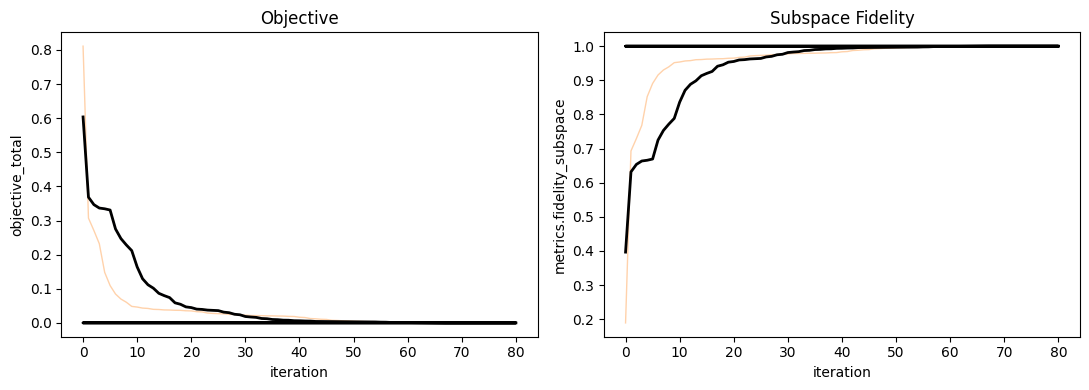

Case A diagnostics:
{'case': 'Case A', 'backend': 'ideal', 'elapsed_s': 203.4921265999874, 'objective_total': 4.6026243256669375e-06, 'fidelity_to_target': 0.9999953973756744, 'leakage_average': 1.850371707708594e-17, 'leakage_worst': 1.1102230246251565e-16, 'history_events': 162, 'selected_start_index': 0}

[Case A] success=False objective=4.60262e-06
metrics: {'fidelity': 0.9999953973756744, 'leakage_average': 1.850371707708594e-17, 'leakage_worst': 1.1102230246251565e-16}
solver settings: {'leakage_n_jobs': 1}
gate sequence:
  QubitRotation_0      type=QubitRotation      duration=  1010.0 ns time_param=t_0
  SQR_1                type=SQR                duration=  1010.0 ns time_param=t_1
  Displacement_2       type=Displacement       duration=  1010.0 ns time_param=t_2
  QubitRotation_3      type=QubitRotation      duration=  1010.0 ns time_param=t_3
  SQR_4                type=SQR                duration=  1010.0 ns time_param=t_4
  Displacement_5       type=Displacement       dura

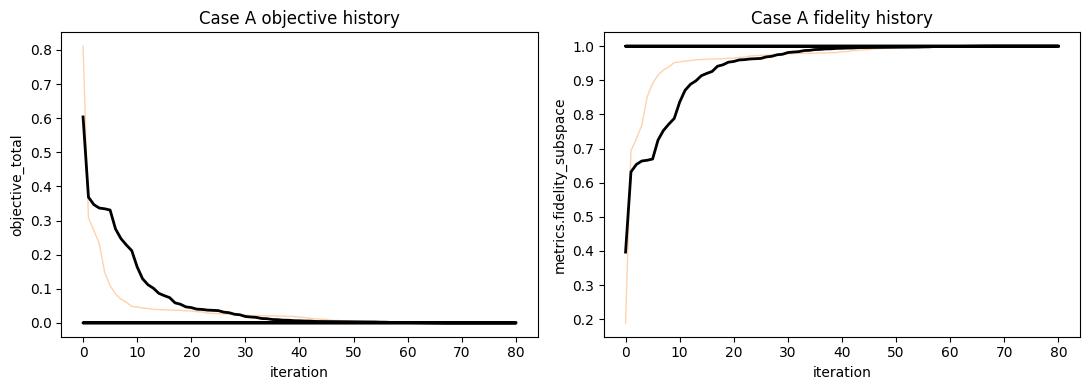

Case A manual subspace fidelity check = 0.999995


In [4]:
progress_ideal = {"enabled": True, "every": 1, "live": True, "print_every": 10}

synth_ideal = UnitarySynthesizer(
    subspace=subspace,
    backend="ideal",
    gateset=IDEAL_GATES,
    optimize_times=False,
    leakage_weight=1.0,
    parallel={"enabled": False, "n_jobs": 1},
    progress=progress_ideal,
    seed=SEED,
)

assert isinstance(synth_ideal.sequence, GateSequence)

start = time.perf_counter()
result_ideal = synth_ideal.fit(
    target=U_target,
    init_guess="random",
    multistart=IDEAL_MULTISTART,
    maxiter=IDEAL_MAXITER,
)
elapsed_ideal = time.perf_counter() - start
report_ideal = make_run_report(result_ideal.report, result_ideal.simulation.subspace_operator)

print_case_diagnostics("Case A", result_ideal, U_target, elapsed_ideal)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_history(result_ideal.history_by_run, what="objective_total", ax=axes[0], title="Case A objective history")
plot_history(result_ideal.history_by_run, what="metrics.fidelity_subspace", ax=axes[1], title="Case A fidelity history")
fig.tight_layout()
plt.show()

ideal_fidelity_check = metrics.subspace_unitary_fidelity(
    result_ideal.simulation.subspace_operator,
    U_target,
)
print(f"Case A manual subspace fidelity check = {ideal_fidelity_check:.6f}")
assert report_ideal["metrics"]["fidelity"] > FIDELITY_GOAL_IDEAL
assert report_ideal["metrics"]["leakage_worst"] < LEAKAGE_GOAL


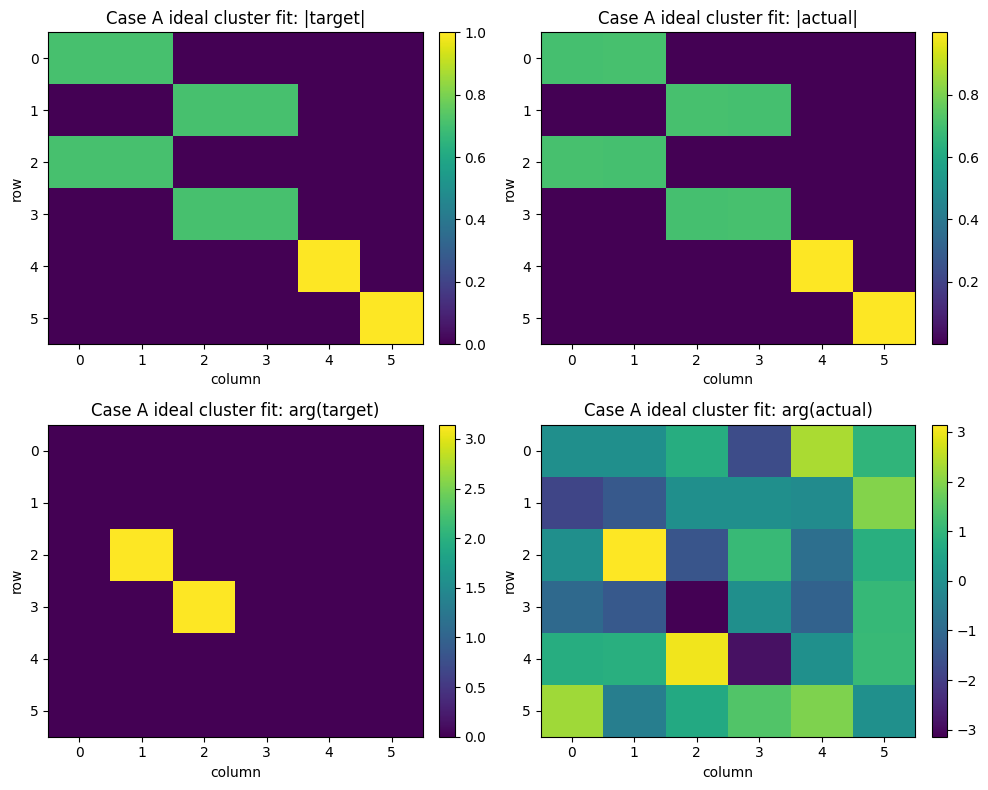

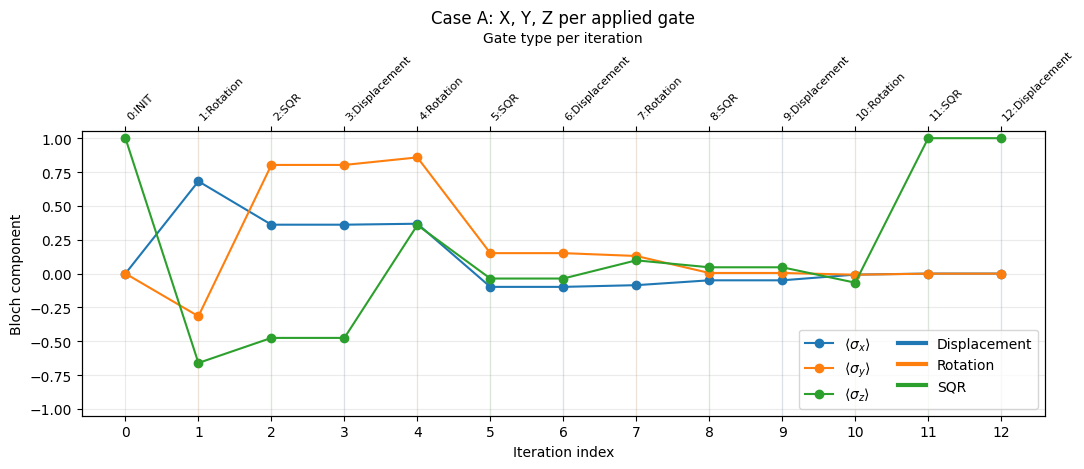

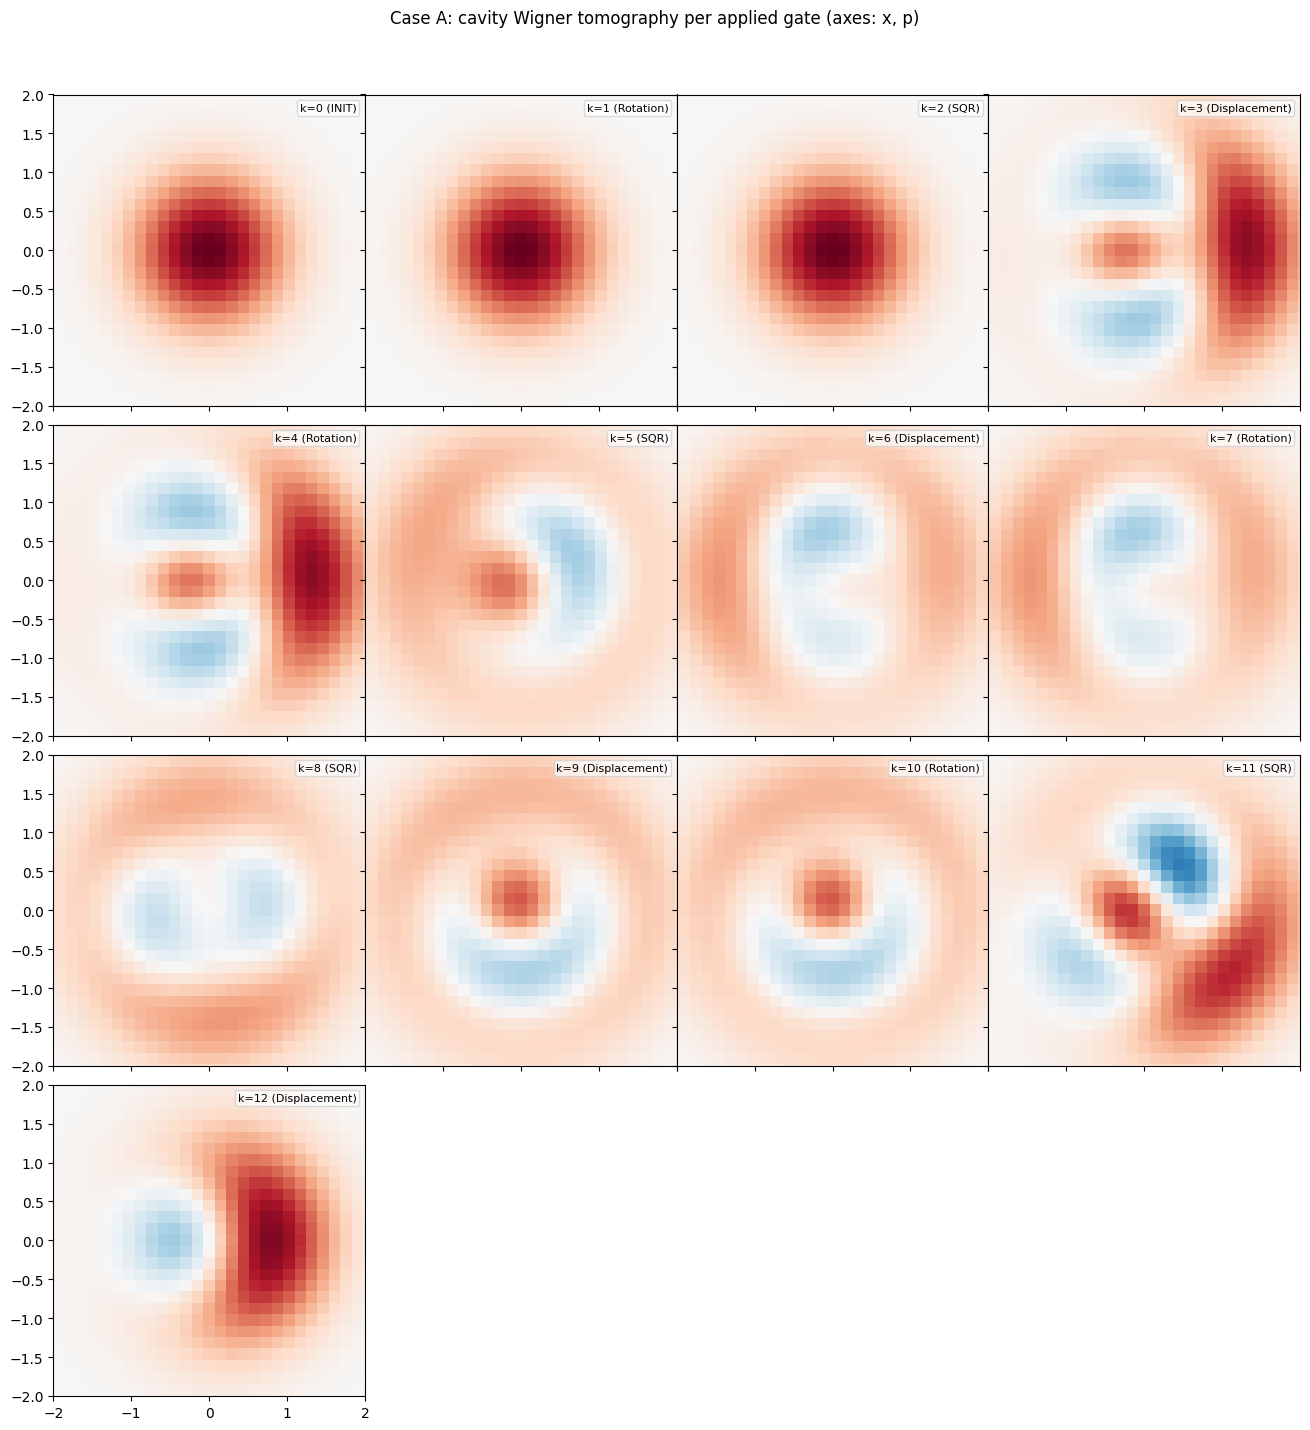

Case A per-Fock 2x2 block summary:
{'n': 0, 'theta_like': 1.5722671265985912, 'phi_like': -1.82476596727778, 'det_phase': 1.0600903310717582}
{'n': 1, 'theta_like': 3.140805289312007, 'phi_like': -3.14133386636775, 'det_phase': -1.0616641971271152}
{'n': 2, 'theta_like': 0.006967152889016238, 'phi_like': 1.9274888787788798, 'det_phase': 0.001389496513160226}
saved: C:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cQED_simulation\outputs\unitary_synthesis_cluster_notebook\cluster_case_a_ideal_report.json
saved: C:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cQED_simulation\outputs\unitary_synthesis_cluster_notebook\cluster_case_a_ideal_history.json
saved: C:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cQED_simulation\outputs\unitary_synthesis_cluster_notebook\cluster_case_a_ideal_history.csv


In [5]:
plot_matrix_comparison(result_ideal.simulation.subspace_operator, U_target, title_prefix="Case A ideal cluster fit")

track_case_a = build_gate_track(result_ideal, backend="ideal", case_name="Case A")
plot_bloch_track(track_case_a, title="Case A: X, Y, Z per applied gate", label_stride=1)
plt.show()

fig = plot_wigner_grid(
    track_case_a,
    title="Case A: cavity Wigner tomography per applied gate",
    stride=1,
    max_cols=WIGNER_MAX_COLS,
)
if fig is not None:
    plt.show()
    plt.close(fig)

ideal_blocks = block_summary(result_ideal.simulation.subspace_operator, subspace)
print("Case A per-Fock 2x2 block summary:")
for row in ideal_blocks:
    print(row)

save_result_artifacts("cluster_case_a_ideal", result_ideal)


## Case B: Pulse-Level Simulation (No Dissipation)

This follows the role of the pulse-level comparison stage highlighted in `tutorials/21_building_sequences_from_gates_and_pulses.ipynb`: a pulse-style simulation compared back to the ideal reference. The gate durations are fixed on the 1 ns grid, and the pulse case includes drift-induced conditional phases through `chi`, `chi2`, and `K`.


In [6]:
pulse_drift = {
    "chi": -2.84e6 * 2 * np.pi,
    "chi2": -22e3 * 2 * np.pi,
    "K": -29e3 * 2 * np.pi,
    "K2": 0.0,
}

drift_model = DriftPhaseModel(
    chi=pulse_drift["chi"],
    chi2=pulse_drift["chi2"],
    kerr=pulse_drift["K"],
    kerr2=pulse_drift["K2"],
)

time_policy = {
    "default": {"optimize": False, "bounds": (16e-9, 1e-6), "init": 16e-9},
    "Displacement": {"optimize": False, "bounds": (48e-9, 48e-9 + 1e-15), "init": 48e-9},
    "QubitRotation": {"optimize": False, "bounds": (16e-9, 16e-9 + 1e-15), "init": 16e-9},
    "SQR": {"optimize": False, "bounds": (1e-6, 1e-6 + 1e-15), "init": 1e-6},
}

time_grid = {"dt": 1e-9, "mode": "hard"}
progress_pulse = {"enabled": True, "every": 5, "live": True, "print_every": 5}

u_drift_ideal = np.asarray(drift_phase_unitary(subspace.full_dim // 2, 1e-6, drift_model).full(), dtype=np.complex128)
u_drift_pulse = np.asarray(drift_phase_from_hamiltonian(subspace.full_dim // 2, 1e-6, drift_model).full(), dtype=np.complex128)
print("drift-only max elementwise mismatch:", np.max(np.abs(u_drift_ideal - u_drift_pulse)))
print(
    "drift-only subspace fidelity:",
    metrics.subspace_unitary_fidelity(
        subspace.restrict_operator(u_drift_pulse),
        subspace.restrict_operator(u_drift_ideal),
    ),
)

synth_pulse = UnitarySynthesizer(
    subspace=subspace,
    backend="pulse",
    gateset=PULSE_GATES,
    optimize_times=False,
    time_policy=time_policy,
    time_grid=time_grid,
    leakage_weight=1.0,
    include_conditional_phase_in_sqr=True,
    drift_config=pulse_drift,
    parallel={"enabled": True, "n_jobs": 6},
    progress=progress_pulse,
    seed=SEED,
)


drift-only max elementwise mismatch: 0.0
drift-only subspace fidelity: 1.0


Case B diagnostics:
{'case': 'Case B', 'backend': 'pulse', 'elapsed_s': 50.362719099997776, 'objective_total': 0.0009502847541805748, 'fidelity_to_target': 0.9990497152458196, 'leakage_average': 9.251858538542972e-17, 'leakage_worst': 2.220446049250313e-16, 'history_events': 18, 'selected_start_index': 1}

[Case B] success=False objective=0.000950285
metrics: {'fidelity': 0.9990497152458196, 'leakage_average': 9.251858538542972e-17, 'leakage_worst': 2.220446049250313e-16}
solver settings: {'leakage_n_jobs': 1}
gate sequence:
  QubitRotation_0      type=QubitRotation      duration=    16.0 ns time_param=t_0
  SQR_1                type=SQR                duration=  1000.0 ns time_param=t_1
  Displacement_2       type=Displacement       duration=    48.0 ns time_param=t_2
  QubitRotation_3      type=QubitRotation      duration=    16.0 ns time_param=t_3
  SQR_4                type=SQR                duration=  1000.0 ns time_param=t_4
  Displacement_5       type=Displacement       duratio

C:\Users\dazzl\AppData\Local\Temp\ipykernel_35320\4081880168.py:75: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(window, t_local)


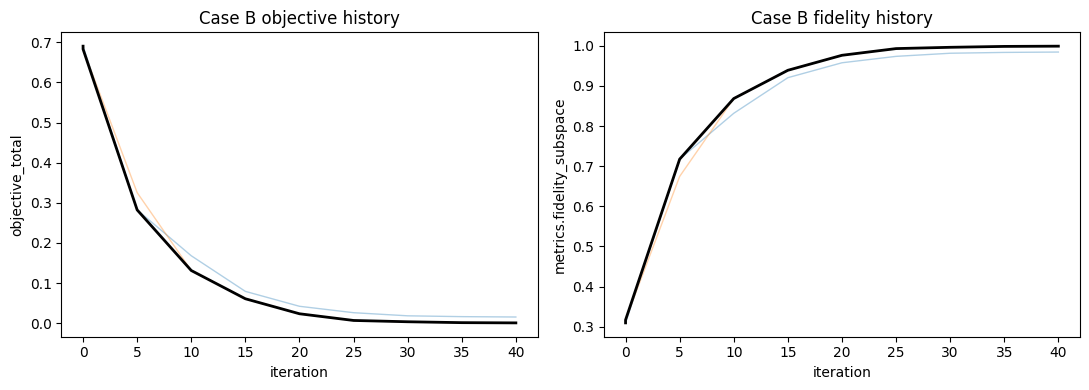

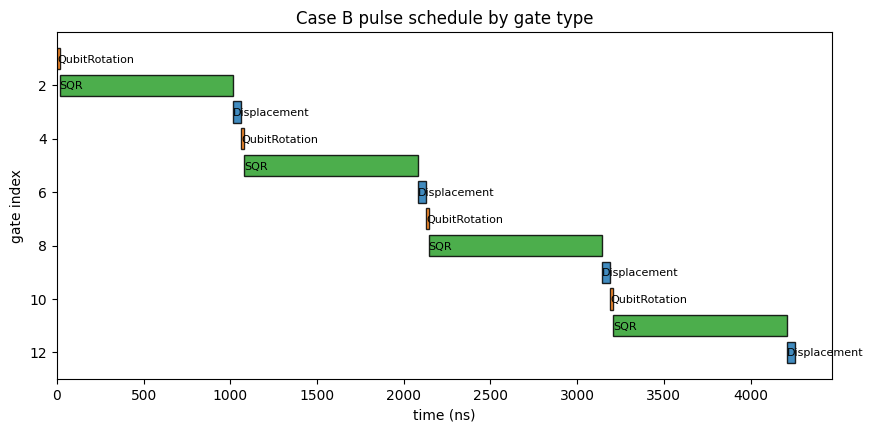

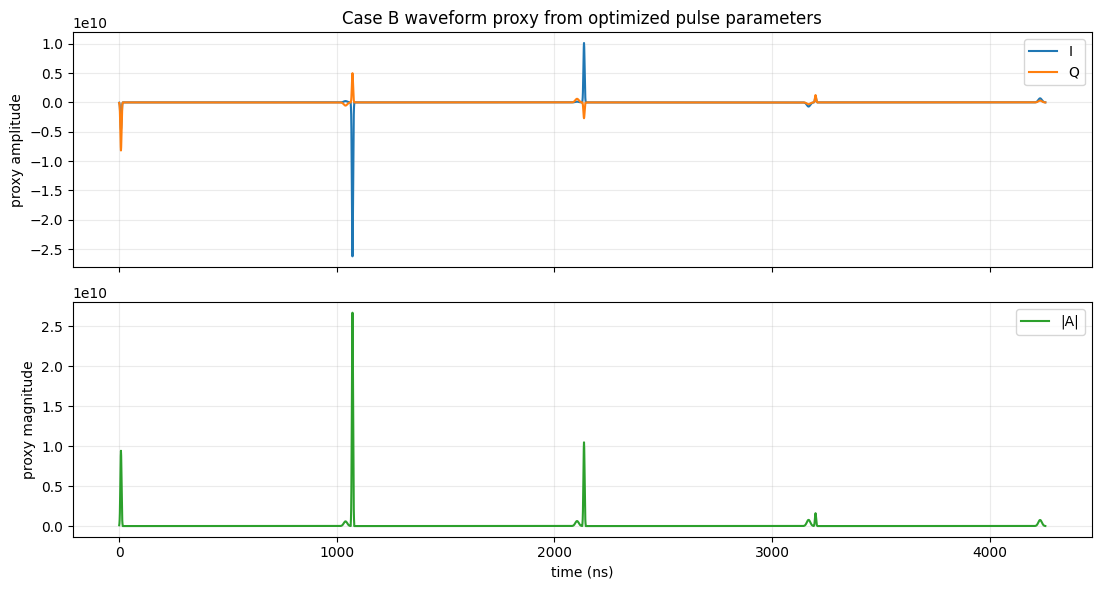

In [7]:
start = time.perf_counter()
result_pulse = synth_pulse.fit(
    target=U_target,
    init_guess="random",
    multistart=PULSE_MULTISTART,
    maxiter=PULSE_MAXITER,
)
elapsed_pulse = time.perf_counter() - start
report_pulse = make_run_report(result_pulse.report, result_pulse.simulation.subspace_operator)

print_case_diagnostics("Case B", result_pulse, U_target, elapsed_pulse)
print_optimized_parameters(result_pulse, label="Case B")
print("fixed durations (ns):", [round(d * 1e9, 3) for d in result_pulse.report["parameters"]["durations"]])
print("Case B gate-to-pulse mapping:")
for row in pulse_mapping_rows(result_pulse):
    print(row)

case_b_waveform = build_waveform_proxy(result_pulse, dt=WAVEFORM_DT)
print("Case B waveform proxy segments:")
for row in case_b_waveform["segments"]:
    print(row)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
plot_history(result_pulse.history_by_run, what="objective_total", ax=axes[0], title="Case B objective history")
plot_history(result_pulse.history_by_run, what="metrics.fidelity_subspace", ax=axes[1], title="Case B fidelity history")
fig.tight_layout()
plt.show()

plot_gate_schedule(result_pulse, title="Case B pulse schedule by gate type")
plot_waveform_proxy(case_b_waveform, title="Case B waveform proxy from optimized pulse parameters")

assert report_pulse["metrics"]["fidelity"] > FIDELITY_GOAL_PULSE
assert report_pulse["metrics"]["leakage_worst"] < LEAKAGE_GOAL


## Case B.1: SQR-Only Duration Compression on the 1 ns Grid

This section keeps the Case B pulse solution as the reference schedule and changes **only** the SQR gate durations.
QubitRotation and Displacement gates remain untouched. The search is a greedy 1 ns-grid compression pass over the SQR durations,
accepting only moves that keep the pulse backend above a chosen fidelity target and below the leakage target.


In [8]:
from copy import deepcopy
from types import SimpleNamespace

from cqed_sim.unitary_synthesis.backends import simulate_sequence

CASE_B_SQR_ONLY_FIDELITY_TARGET = 0.99
CASE_B_SQR_ONLY_MIN_NS = 200
CASE_B_SQR_ONLY_STEPS_NS = (200, 100, 50, 20, 10, 5, 2, 1)


def sqr_gate_rows(sequence) -> list[dict]:
    rows = []
    for gate_index, gate in enumerate(sequence.gates):
        if gate.type != "SQR":
            continue
        rows.append(
            {
                "global_index": int(gate_index),
                "gate_name": str(gate.name),
                "duration_ns": float(gate.duration * 1e9),
            }
        )
    return rows


def sequence_total_duration_ns(sequence) -> float:
    return float(sum(float(gate.duration) for gate in sequence.gates) * 1e9)


def sequence_with_sqr_durations_ns(sequence, sqr_durations_ns):
    seq = deepcopy(sequence)
    sqr_rows = sqr_gate_rows(seq)
    values = [int(round(x)) for x in sqr_durations_ns]
    if len(values) != len(sqr_rows):
        raise ValueError("SQR duration vector length mismatch.")
    for row, duration_ns in zip(sqr_rows, values, strict=True):
        gate_index = row["global_index"]
        duration_s = float(duration_ns) * 1e-9
        gate = seq.gates[gate_index]
        gate.duration = duration_s
        gate.time_bounds = (float(CASE_B_SQR_ONLY_MIN_NS) * 1e-9, max(float(row["duration_ns"]) * 1e-9, duration_s))
        if hasattr(seq, "_gate_time_param_indices"):
            param_index = seq._gate_time_param_indices[gate_index]
            param = seq.time_params[param_index]
            param.t_min = float(CASE_B_SQR_ONLY_MIN_NS) * 1e-9
            param.t_max = max(float(row["duration_ns"]) * 1e-9, duration_s)
            param.t_init = duration_s
            param.value = duration_s
    if hasattr(seq, "_apply_time_params_to_gates"):
        seq._apply_time_params_to_gates()
    return seq


case_b_sqr_eval_cache = {}


def evaluate_case_b_sqr_only(sqr_durations_ns):
    key = tuple(int(round(x)) for x in sqr_durations_ns)
    if key in case_b_sqr_eval_cache:
        return case_b_sqr_eval_cache[key]
    seq = sequence_with_sqr_durations_ns(result_pulse.sequence, key)
    sim = simulate_sequence(
        seq,
        subspace,
        backend="pulse",
        target_subspace=U_target,
        leakage_weight=1.0,
    )
    record = {
        "sqr_durations_ns": [int(x) for x in key],
        "total_duration_ns": float(sequence_total_duration_ns(seq)),
        "fidelity": float(sim.metrics["fidelity"]),
        "leakage_average": float(sim.metrics["leakage_average"]),
        "leakage_worst": float(sim.metrics["leakage_worst"]),
        "objective": float(sim.metrics["objective"]),
        "sequence": seq,
        "simulation": sim,
    }
    case_b_sqr_eval_cache[key] = record
    return record


def greedy_sqr_only_duration_compression(initial_sqr_ns, fidelity_target, leakage_goal, min_ns, steps_ns):
    current = np.asarray([int(round(x)) for x in initial_sqr_ns], dtype=int)
    current_eval = evaluate_case_b_sqr_only(current)
    history = [
        {
            "accepted": True,
            "step_ns": 0,
            "changed_gate": None,
            "gate_name": None,
            "sqr_durations_ns": list(current_eval["sqr_durations_ns"]),
            "total_duration_ns": float(current_eval["total_duration_ns"]),
            "fidelity": float(current_eval["fidelity"]),
            "leakage_worst": float(current_eval["leakage_worst"]),
        }
    ]
    gate_rows = sqr_gate_rows(result_pulse.sequence)

    for step_ns in [int(x) for x in steps_ns]:
        improved = True
        while improved:
            improved = False
            candidates = []
            for local_idx, gate_row in enumerate(gate_rows):
                trial = current.copy()
                if trial[local_idx] - step_ns < int(min_ns):
                    continue
                trial[local_idx] -= step_ns
                trial_eval = evaluate_case_b_sqr_only(trial)
                feasible = (
                    float(trial_eval["fidelity"]) >= float(fidelity_target)
                    and float(trial_eval["leakage_worst"]) <= float(leakage_goal)
                )
                history.append(
                    {
                        "accepted": bool(feasible),
                        "step_ns": int(step_ns),
                        "changed_gate": int(local_idx),
                        "gate_name": str(gate_row["gate_name"]),
                        "sqr_durations_ns": [int(x) for x in trial_eval["sqr_durations_ns"]],
                        "total_duration_ns": float(trial_eval["total_duration_ns"]),
                        "fidelity": float(trial_eval["fidelity"]),
                        "leakage_worst": float(trial_eval["leakage_worst"]),
                    }
                )
                if feasible:
                    candidates.append((trial.copy(), trial_eval, gate_row))
            if candidates:
                candidates.sort(
                    key=lambda item: (
                        float(item[1]["total_duration_ns"]),
                        -float(item[1]["fidelity"]),
                        float(item[1]["leakage_worst"]),
                        tuple(int(x) for x in item[1]["sqr_durations_ns"]),
                    )
                )
                current = candidates[0][0]
                current_eval = candidates[0][1]
                improved = True
    return current_eval, history


def plot_sqr_compression_history(history_rows, title: str) -> None:
    hist = pd.DataFrame(history_rows)
    accepted = hist[hist["accepted"]].reset_index(drop=True)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(accepted.index, accepted["total_duration_ns"], marker="o", color="tab:blue")
    axes[0].set_xlabel("accepted move")
    axes[0].set_ylabel("full sequence duration (ns)")
    axes[0].grid(alpha=0.25)
    axes[1].plot(accepted["total_duration_ns"], accepted["fidelity"], marker="o", color="tab:green")
    axes[1].axhline(CASE_B_SQR_ONLY_FIDELITY_TARGET, linestyle="--", color="tab:red", label="fidelity target")
    axes[1].set_xlabel("full sequence duration (ns)")
    axes[1].set_ylabel("subspace fidelity")
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc="best")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


def plot_waveform_proxy_overlay(reference_waveform, candidate_waveform, title: str) -> None:
    fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
    axes[0].plot(reference_waveform["t_ns"], reference_waveform["i"], color="tab:blue", alpha=0.85, label="baseline I")
    axes[0].plot(reference_waveform["t_ns"], reference_waveform["q"], color="tab:orange", alpha=0.85, label="baseline Q")
    axes[0].plot(candidate_waveform["t_ns"], candidate_waveform["i"], color="tab:cyan", linestyle="--", label="compressed I")
    axes[0].plot(candidate_waveform["t_ns"], candidate_waveform["q"], color="tab:red", linestyle="--", label="compressed Q")
    axes[0].set_ylabel("proxy amplitude")
    axes[0].set_title(title)
    axes[0].grid(alpha=0.25)
    axes[0].legend(loc="best", ncol=2)
    axes[1].plot(reference_waveform["t_ns"], reference_waveform["mag"], color="tab:green", alpha=0.85, label="baseline |A|")
    axes[1].plot(candidate_waveform["t_ns"], candidate_waveform["mag"], color="tab:purple", linestyle="--", label="compressed |A|")
    axes[1].set_xlabel("time (ns)")
    axes[1].set_ylabel("proxy magnitude")
    axes[1].grid(alpha=0.25)
    axes[1].legend(loc="best")
    fig.tight_layout()
    plt.show()


C:\Users\dazzl\AppData\Local\Temp\ipykernel_35320\4081880168.py:75: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  area = np.trapz(window, t_local)


,gate_name,baseline_ns,compressed_ns,saved_ns
0,SQR_1,1000,1000,0
1,SQR_4,1000,995,5
2,SQR_7,1000,995,5
3,SQR_10,1000,1000,0


Case B SQR-only compression summary:
{
  "fidelity_target": 0.99,
  "baseline_total_duration_ns": 4256.000000000001,
  "compressed_total_duration_ns": 4246.000000000001,
  "saved_total_ns": 10.0,
  "saved_fraction": 0.0023496240601503754,
  "baseline_fidelity": 0.9990497152458196,
  "compressed_fidelity": 0.9901098799685081,
  "baseline_leakage_worst": 2.220446049250313e-16,
  "compressed_leakage_worst": 1.1102230246251565e-16,
  "baseline_sqr_durations_ns": [
    1000,
    1000,
    1000,
    1000
  ],
  "compressed_sqr_durations_ns": [
    1000,
    995,
    995,
    1000
  ]
}
saved: C:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cQED_simulation\outputs\unitary_synthesis_cluster_notebook\cluster_case_b_sqr_only_duration_compression.json


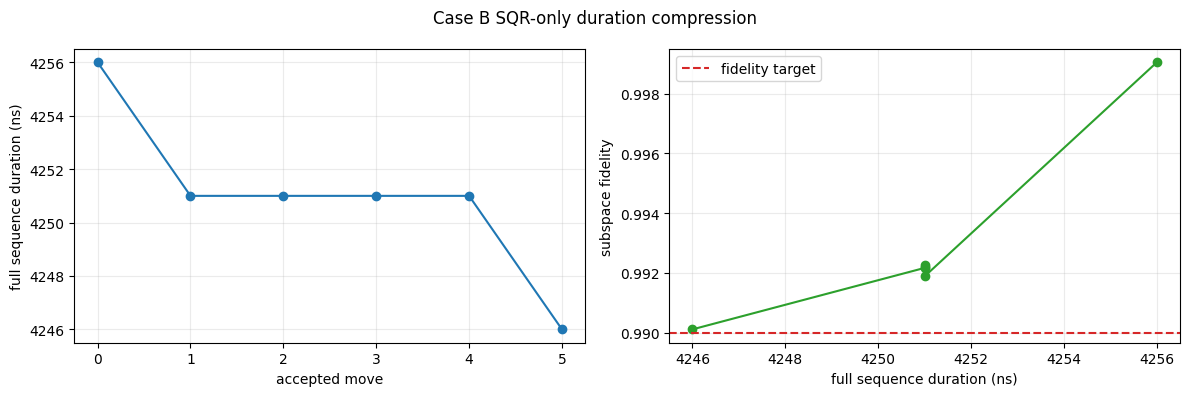

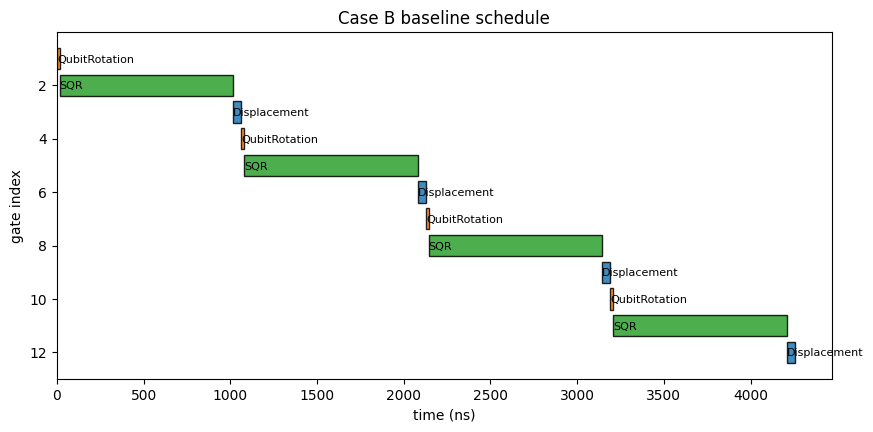

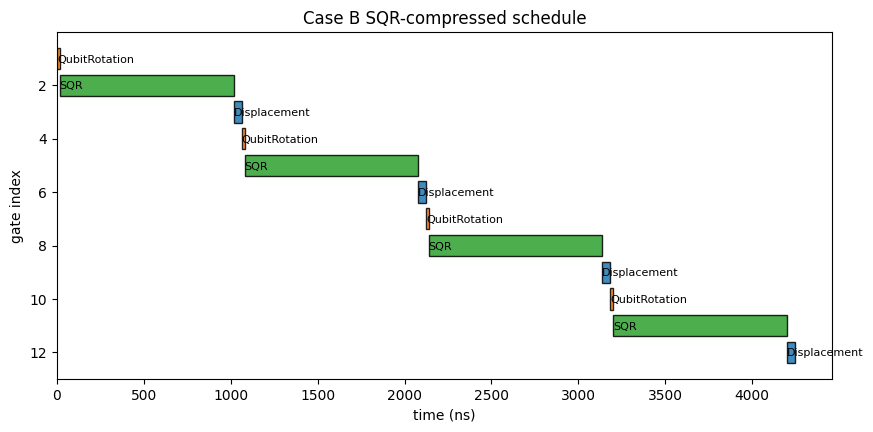

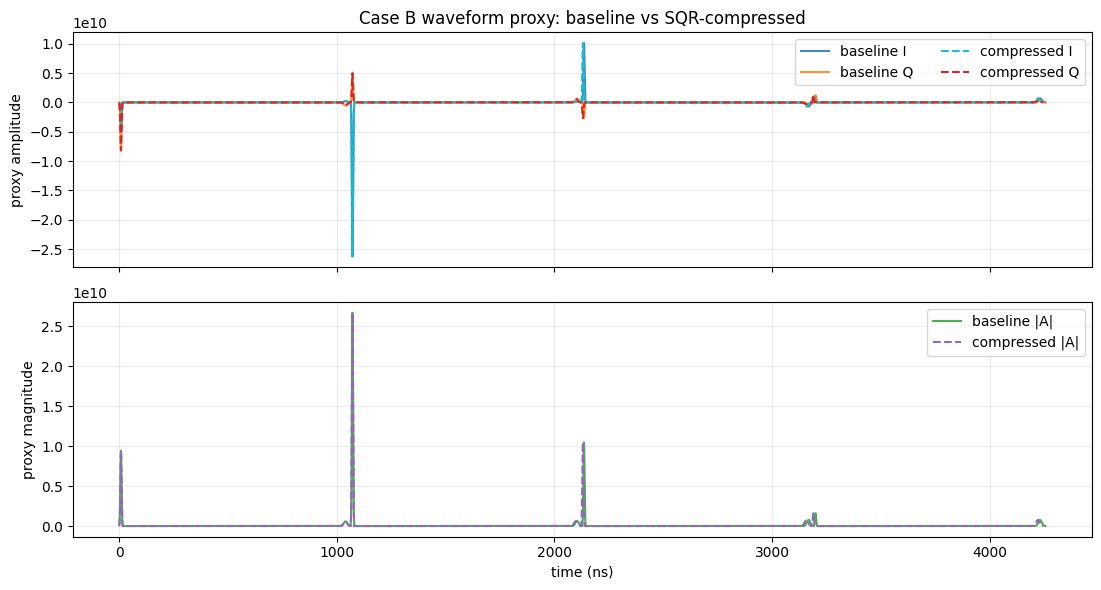

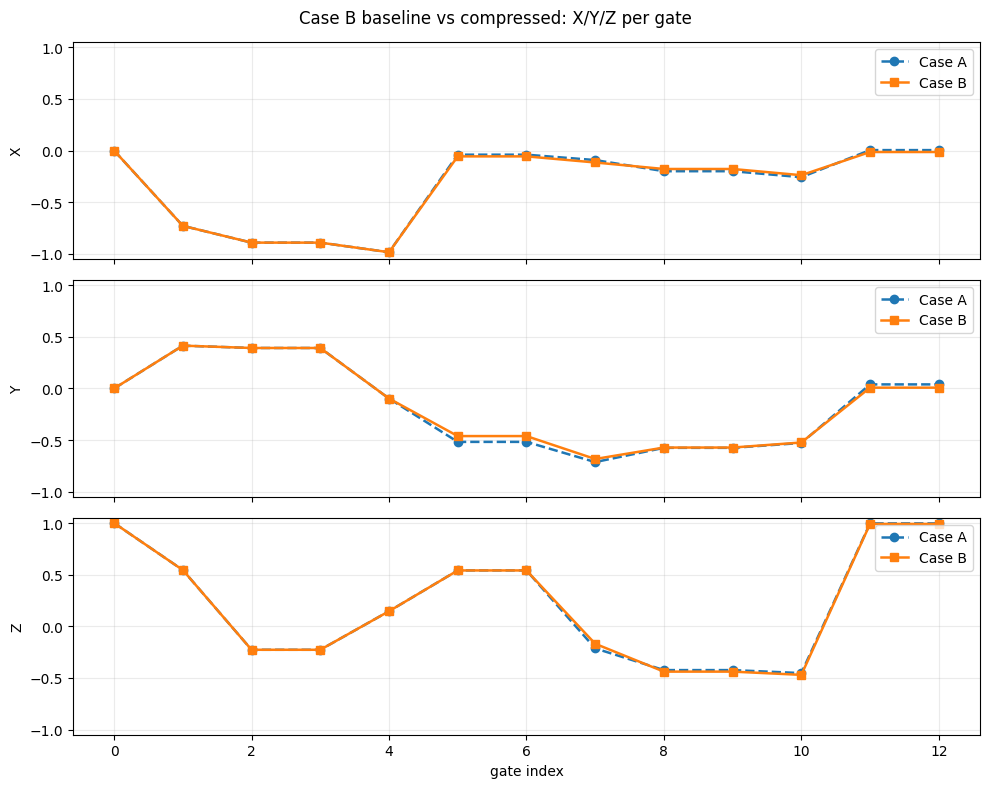

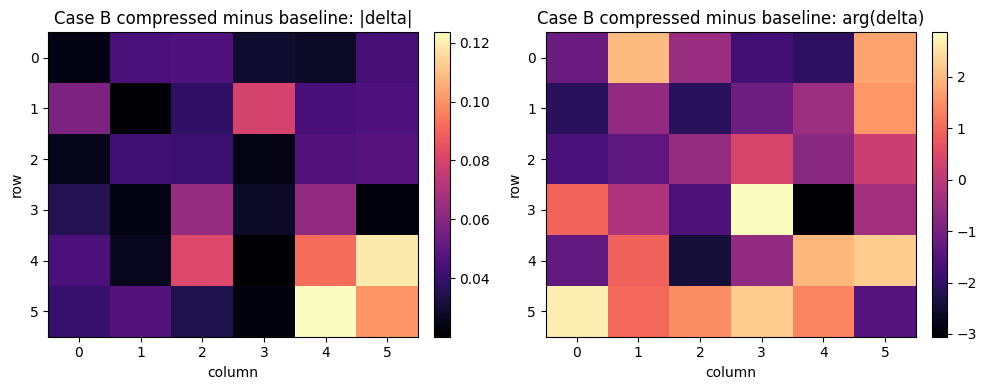

In [9]:
baseline_sqr_rows = sqr_gate_rows(result_pulse.sequence)
baseline_sqr_ns = [int(round(row["duration_ns"])) for row in baseline_sqr_rows]
case_b_baseline_eval = evaluate_case_b_sqr_only(baseline_sqr_ns)
case_b_compressed_eval, case_b_sqr_history = greedy_sqr_only_duration_compression(
    initial_sqr_ns=baseline_sqr_ns,
    fidelity_target=CASE_B_SQR_ONLY_FIDELITY_TARGET,
    leakage_goal=LEAKAGE_GOAL,
    min_ns=CASE_B_SQR_ONLY_MIN_NS,
    steps_ns=CASE_B_SQR_ONLY_STEPS_NS,
)

compressed_sequence = case_b_compressed_eval["sequence"]
compressed_simulation = case_b_compressed_eval["simulation"]
compressed_waveform = build_waveform_proxy(SimpleNamespace(sequence=compressed_sequence), dt=WAVEFORM_DT)

compression_rows = []
for row, compressed_ns in zip(baseline_sqr_rows, case_b_compressed_eval["sqr_durations_ns"], strict=True):
    compression_rows.append(
        {
            "gate_name": row["gate_name"],
            "baseline_ns": int(round(row["duration_ns"])),
            "compressed_ns": int(round(compressed_ns)),
            "saved_ns": int(round(row["duration_ns"])) - int(round(compressed_ns)),
        }
    )
compression_df = pd.DataFrame(compression_rows)
display(compression_df)

compression_summary = {
    "fidelity_target": float(CASE_B_SQR_ONLY_FIDELITY_TARGET),
    "baseline_total_duration_ns": float(case_b_baseline_eval["total_duration_ns"]),
    "compressed_total_duration_ns": float(case_b_compressed_eval["total_duration_ns"]),
    "saved_total_ns": float(case_b_baseline_eval["total_duration_ns"] - case_b_compressed_eval["total_duration_ns"]),
    "saved_fraction": float((case_b_baseline_eval["total_duration_ns"] - case_b_compressed_eval["total_duration_ns"]) / case_b_baseline_eval["total_duration_ns"]),
    "baseline_fidelity": float(case_b_baseline_eval["fidelity"]),
    "compressed_fidelity": float(case_b_compressed_eval["fidelity"]),
    "baseline_leakage_worst": float(case_b_baseline_eval["leakage_worst"]),
    "compressed_leakage_worst": float(case_b_compressed_eval["leakage_worst"]),
    "baseline_sqr_durations_ns": [int(x) for x in case_b_baseline_eval["sqr_durations_ns"]],
    "compressed_sqr_durations_ns": [int(x) for x in case_b_compressed_eval["sqr_durations_ns"]],
}
print("Case B SQR-only compression summary:")
print(json.dumps(compression_summary, indent=2))

compression_payload = {
    "summary": compression_summary,
    "per_gate": compression_rows,
    "history": case_b_sqr_history,
}
compression_path = OUTPUT_DIR / "cluster_case_b_sqr_only_duration_compression.json"
compression_path.write_text(json.dumps(compression_payload, indent=2), encoding="utf-8")
print(f"saved: {compression_path}")

plot_sqr_compression_history(case_b_sqr_history, title="Case B SQR-only duration compression")
plot_gate_schedule(SimpleNamespace(sequence=result_pulse.sequence), title="Case B baseline schedule")
plot_gate_schedule(SimpleNamespace(sequence=compressed_sequence), title="Case B SQR-compressed schedule")
plot_waveform_proxy_overlay(case_b_waveform, compressed_waveform, title="Case B waveform proxy: baseline vs SQR-compressed")

baseline_track_case_b = build_gate_track(result_pulse, backend="pulse", case_name="Case B baseline")
compressed_track_case_b = build_gate_track(SimpleNamespace(sequence=compressed_sequence), backend="pulse", case_name="Case B compressed")
plot_bloch_overlay(baseline_track_case_b, compressed_track_case_b, title="Case B baseline vs compressed: X/Y/Z per gate")
plot_delta_heatmap(
    result_pulse.simulation.subspace_operator,
    compressed_simulation.subspace_operator,
    title_prefix="Case B compressed minus baseline",
)


## Case A vs Case B: Reference Comparison

As in the staged workflow summarized by Tutorials 21 and 22, the pulse case is interpreted relative to the ideal reference. The comparison below treats `Case A` as the baseline and reports how closely `Case B` reproduces the fitted subspace action.


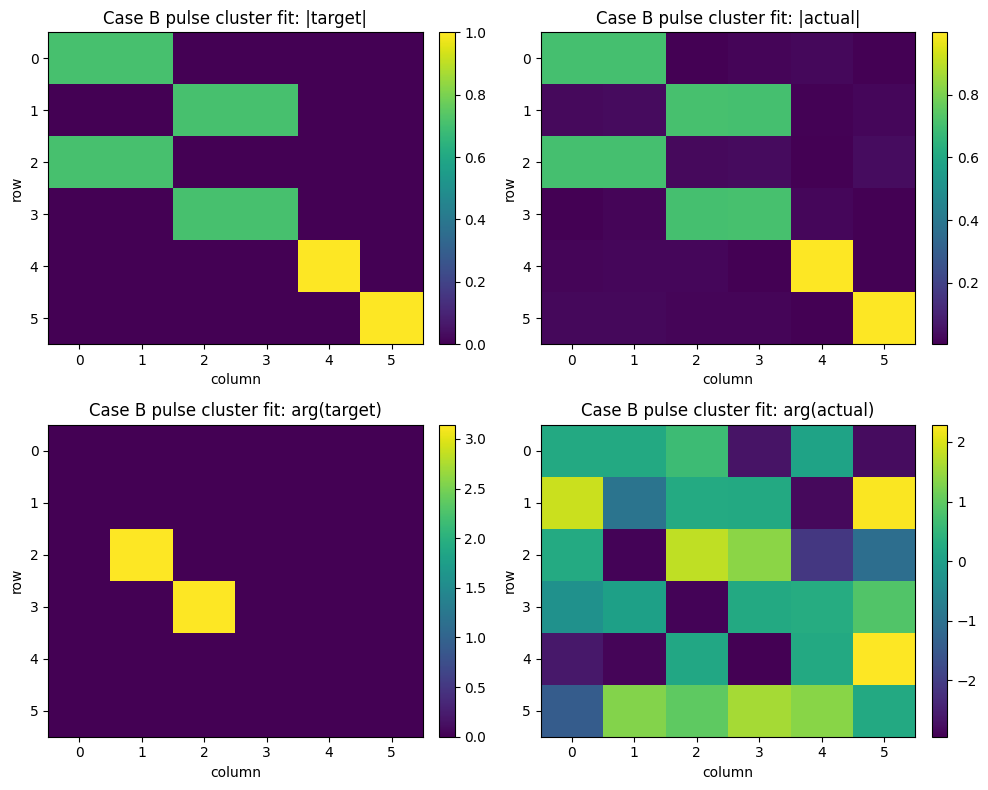

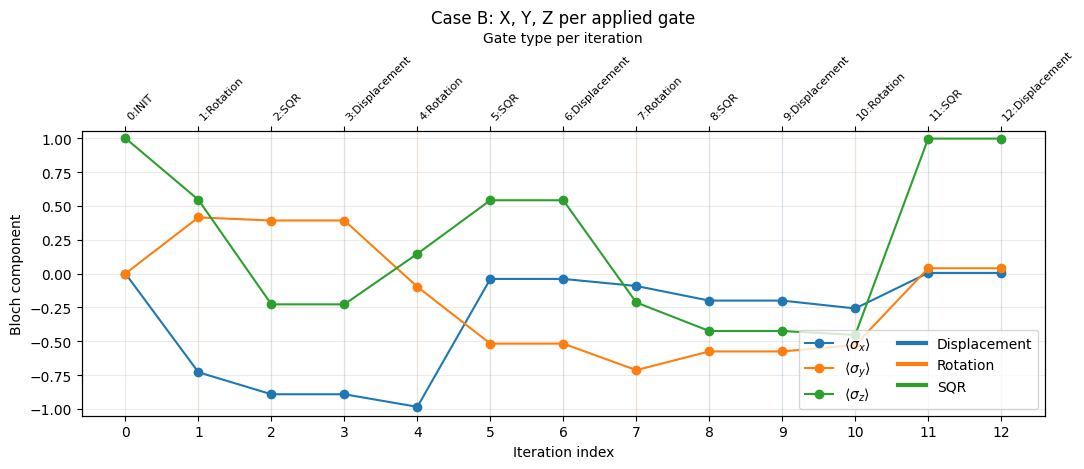

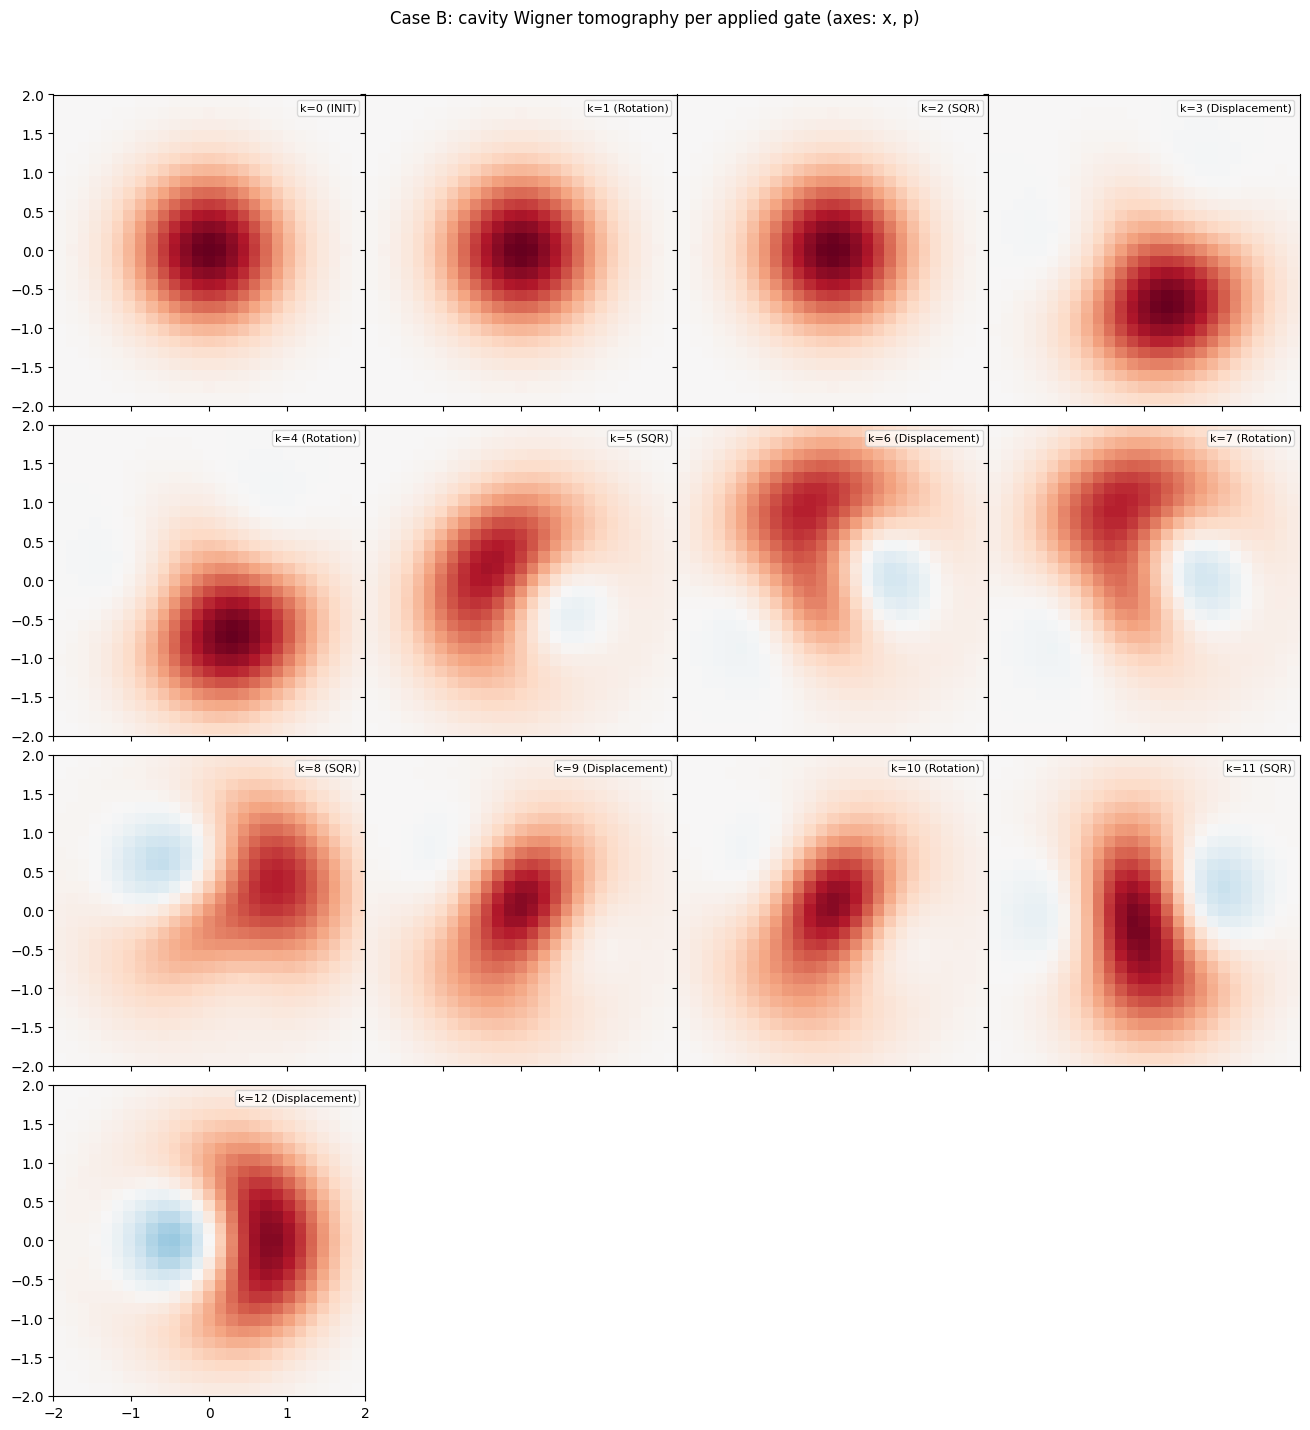

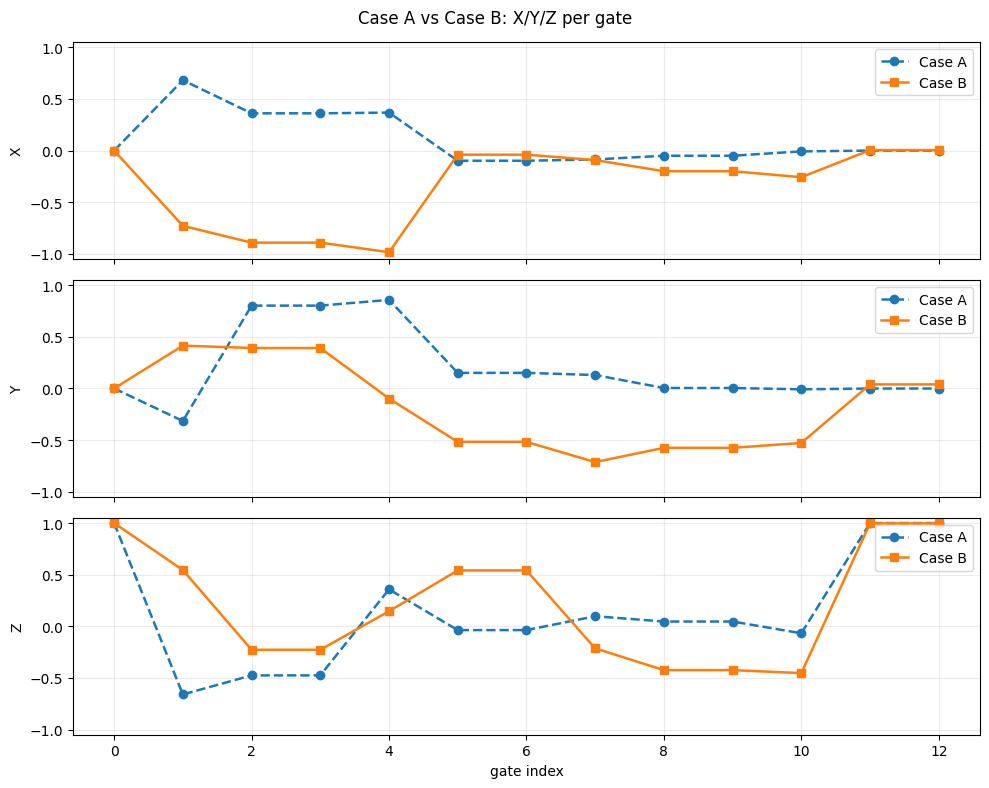

Case B per-Fock block summary:
{'n': 0, 'theta_like': 1.57164005933885, 'phi_like': 1.8624590156424243, 'det_phase': -0.8601813959815005}
{'n': 1, 'theta_like': 3.0815838308419075, 'phi_like': -2.8941137957887206, 'det_phase': 1.8172121197420048}
{'n': 2, 'theta_like': 0.07249933416292063, 'phi_like': 1.3547481624628612, 'det_phase': 0.4834859907408764}
Case A vs Case B:
{'candidate_vs_reference_fidelity': 0.9990221945889619, 'frobenius_distance': 0.6031679518347305, 'max_abs_difference': 0.24063202924982022, 'candidate_objective_minus_reference': 0.0009456821298549078, 'candidate_leakage_minus_reference': 1.1102230246251565e-16}


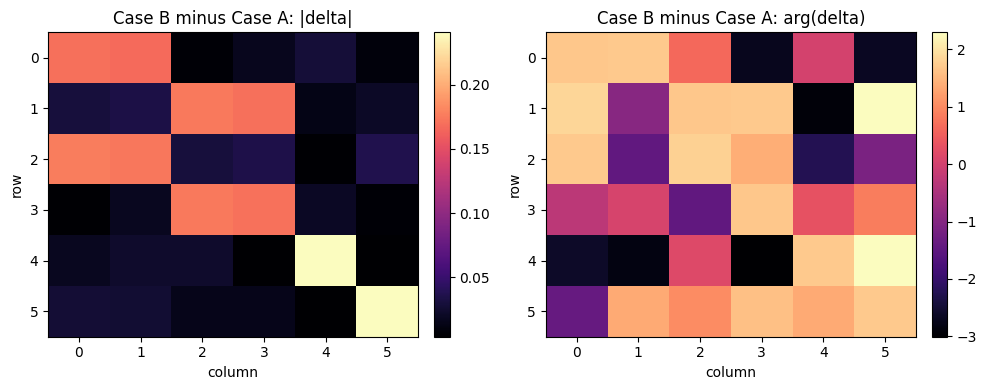

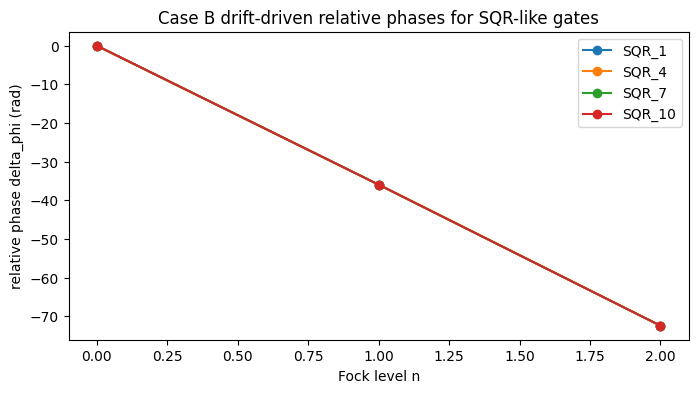

saved: C:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cQED_simulation\outputs\unitary_synthesis_cluster_notebook\cluster_case_b_pulse_report.json
saved: C:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cQED_simulation\outputs\unitary_synthesis_cluster_notebook\cluster_case_b_pulse_history.json
saved: C:\Users\dazzl\Box\Shyam Shankar Quantum Circuits Group\Users\Users_JianJun\cQED_simulation\outputs\unitary_synthesis_cluster_notebook\cluster_case_b_pulse_history.csv


In [10]:
plot_matrix_comparison(result_pulse.simulation.subspace_operator, U_target, title_prefix="Case B pulse cluster fit")

track_case_b = build_gate_track(result_pulse, backend="pulse", case_name="Case B")
plot_bloch_track(track_case_b, title="Case B: X, Y, Z per applied gate", label_stride=1)
plt.show()

fig = plot_wigner_grid(
    track_case_b,
    title="Case B: cavity Wigner tomography per applied gate",
    stride=1,
    max_cols=WIGNER_MAX_COLS,
)
if fig is not None:
    plt.show()
    plt.close(fig)

plot_bloch_overlay(track_case_a, track_case_b, title="Case A vs Case B: X/Y/Z per gate")

pulse_blocks = block_summary(result_pulse.simulation.subspace_operator, subspace)
print("Case B per-Fock block summary:")
for row in pulse_blocks:
    print(row)

comparison_ab = case_comparison_summary(result_ideal, result_pulse)
print("Case A vs Case B:")
print(comparison_ab)
plot_delta_heatmap(
    result_ideal.simulation.subspace_operator,
    result_pulse.simulation.subspace_operator,
    title_prefix="Case B minus Case A",
)

phase_rows = [
    row
    for row in result_pulse.report["phase_decomposition"]
    if row.get("gate_type") in {"SQR", "FreeEvolveCondPhase"}
]
if phase_rows:
    fig, ax = plt.subplots(figsize=(8, 4))
    for row in phase_rows:
        if not row.get("enabled", False):
            continue
        ax.plot(row["n"], row["delta_phi"], marker="o", label=row["gate_name"])
    ax.set_xlabel("Fock level n")
    ax.set_ylabel("relative phase delta_phi (rad)")
    ax.set_title("Case B drift-driven relative phases for SQR-like gates")
    ax.legend(loc="best")
    plt.show()

save_result_artifacts("cluster_case_b_pulse", result_pulse)


## Case A ZXZ Correlation via `holographic_sim_cached`

This uses the cached holographic simulator from `JJL_Experiments/holographic_sim/holographicSim.py`.

Following the pattern in `simulations/holographic_sim/simulation.ipynb`, the full `Case A` synthesized unitary is used as the repeated site channel:

- build `U_total` from the optimized `Case A` gate unitaries,
- make `N` copies of that channel,
- evaluate the repeated-site `\langle Z_i X_{i+1} Z_{i+2} 
angle` correlator.


Case A full-unitary reconstruction error: 2.2530044628618934e-16
Case A gate-order diagnostic: {'forward_error': 2.2530044628618934e-16, 'reverse_error': 1.413977998627183}
Case A ZXZ center correlator mean = 0.999918
Representative cached branch table (center ZXZ placement):
    s8   s9  s10      prob    weight
0  1.0  1.0  1.0  0.249867  1.0+0.0j
1  1.0  1.0 -1.0  0.000003 -1.0+0.0j
2  1.0 -1.0  1.0  0.000032 -1.0+0.0j
3  1.0 -1.0 -1.0  0.249962  1.0+0.0j
4 -1.0  1.0  1.0  0.000004 -1.0+0.0j


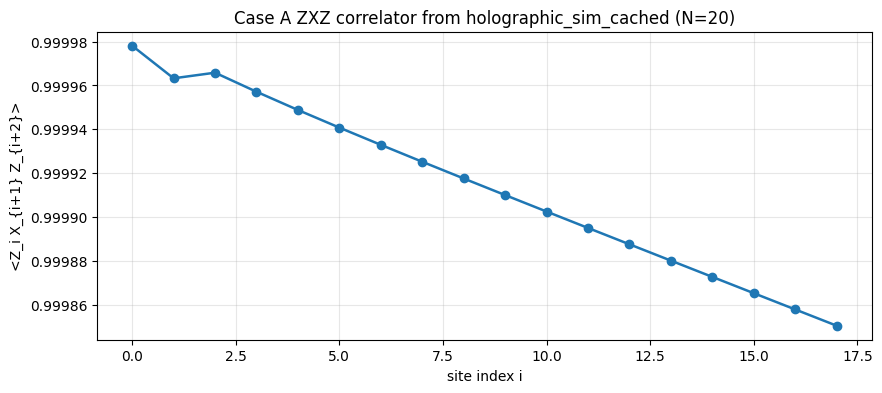

In [11]:
U_case_a_total = compute_case_a_total_unitary_from_gates(result_ideal)
print("Case A full-unitary reconstruction error:", np.max(np.abs(U_case_a_total - result_ideal.simulation.full_operator)))
print("Case A gate-order diagnostic:", verify_gate_ordering(result_ideal))

zxz_curve_case_a, zxz_center_mean, zxz_center_df = compute_zxz_curve_cached(
    U_case_a_total,
    n_sites=HOLOGRAPHIC_N,
    shot_nums=HOLOGRAPHIC_SHOTS,
)
print(f"Case A ZXZ center correlator mean = {zxz_center_mean:.6f}")
print("Representative cached branch table (center ZXZ placement):")
print(zxz_center_df.head())

plt.figure(figsize=(10, 4))
plt.plot(zxz_curve_case_a, marker="o", linewidth=1.8)
plt.title(f"Case A ZXZ correlator from holographic_sim_cached (N={HOLOGRAPHIC_N})")
plt.xlabel("site index i")
plt.ylabel("<Z_i X_{i+1} Z_{i+2}>")
plt.grid(alpha=0.3)
plt.show()


## Apply `holographic_sim_cached` to Another Unitary

The same cached ZXZ workflow can be reused for any unitary of matching dimension.

By default below, `U_this_total` is set to the optimized **Case B** full operator, but you can replace it with any other unitary matrix.


Selected unitary shape: (6, 6)
Selected unitary unitarity error: 1.2913326907644547e-15


Selected-unitary ZXZ center correlator mean = 0.999918
Representative cached branch table (selected unitary, center ZXZ placement):
    s8   s9  s10      prob    weight
0  1.0  1.0  1.0  0.249867  1.0+0.0j
1  1.0  1.0 -1.0  0.000003 -1.0+0.0j
2  1.0 -1.0  1.0  0.000032 -1.0+0.0j
3  1.0 -1.0 -1.0  0.249962  1.0+0.0j
4 -1.0  1.0  1.0  0.000004 -1.0+0.0j


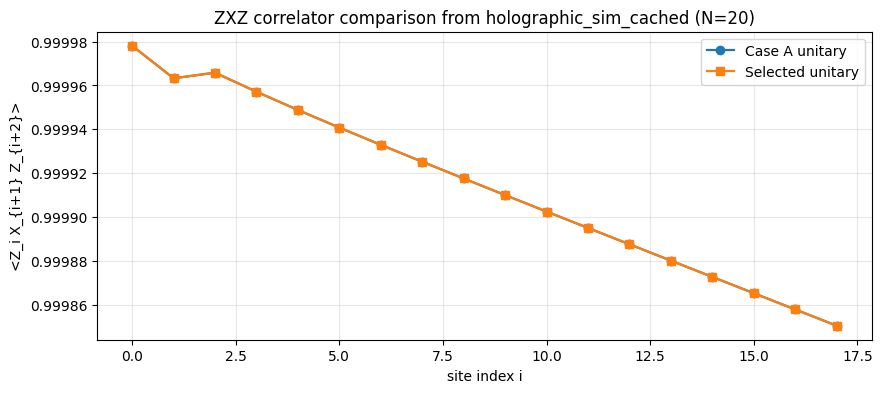

Center-mean delta (selected - Case A): 0.0


In [12]:
# Choose the unitary you want to probe with holographic_sim_cached.
# Default: Case A full operator, since this is the cluster reference sanity check.
U_this_total = np.asarray(U_case_a_total, dtype=np.complex128)

print("Selected unitary shape:", U_this_total.shape)
print(
    "Selected unitary unitarity error:",
    np.linalg.norm(U_this_total.conj().T @ U_this_total - np.eye(U_this_total.shape[0], dtype=np.complex128)),
)

zxz_curve_this, zxz_this_center_mean, zxz_this_center_df = compute_zxz_curve_cached(
    U_this_total,
    n_sites=HOLOGRAPHIC_N,
    shot_nums=HOLOGRAPHIC_SHOTS,
)

print(f"Selected-unitary ZXZ center correlator mean = {zxz_this_center_mean:.6f}")
print("Representative cached branch table (selected unitary, center ZXZ placement):")
print(zxz_this_center_df.head())

plt.figure(figsize=(10, 4))
plt.plot(zxz_curve_case_a, marker="o", linewidth=1.6, label="Case A unitary")
plt.plot(zxz_curve_this, marker="s", linewidth=1.6, label="Selected unitary")
plt.title(f"ZXZ correlator comparison from holographic_sim_cached (N={HOLOGRAPHIC_N})")
plt.xlabel("site index i")
plt.ylabel("<Z_i X_{i+1} Z_{i+2}>")
plt.grid(alpha=0.3)
plt.legend(loc="best")
plt.show()

print("Center-mean delta (selected - Case A):", float(zxz_this_center_mean - zxz_center_mean))


## Single-Site Correlators via `holographic_sim_cached`

Compute the one-point expectations `\langle X_i \rangle`, `\langle Y_i \rangle`, and `\langle Z_i \rangle` across site index `i` for a repeated-site channel built from the selected unitary.
`holographicSim` expects each site unitary in `qubit ? bond` ordering. The synthesized operators in this notebook already use `qubit ? cavity`, so the helper below only validates dimensions before computing one-point functions.

These one-point functions are the cluster-state sanity check. They are different from the ancilla Bloch track plotted gate-by-gate above.


Single-site center values:
{'center_index': 10, '<X_center>': 7.105394214712568e-05, '<Y_center>': -0.0007150207231382821, '<Z_center>': -0.00025739685420800296}
Bulk max |<X>|, |<Y>|, |<Z>| (excluding site 0 reset boundary; site 0 carries the reset boundary):
{'max_abs_x_bulk': 0.0002591620667262151, 'max_abs_y_bulk': 0.0007210746278943359, 'max_abs_z_bulk': 0.0012056047778366552}


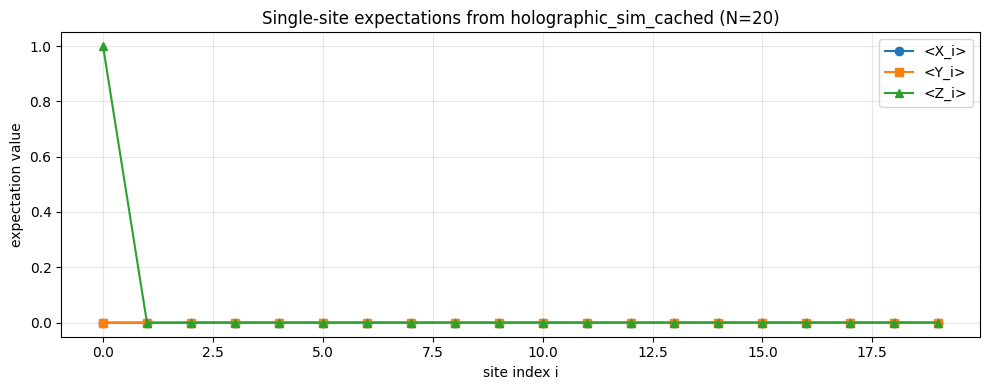

In [13]:
PAULI_Y_HOLO = np.array([[0.0, -1.0j], [1.0j, 0.0]], dtype=np.complex128)


def compute_single_site_curve_cached(U_total: np.ndarray, op: np.ndarray, n_sites: int = HOLOGRAPHIC_N, shot_nums: int = HOLOGRAPHIC_SHOTS):
    U_sys_bond = to_system_bond_order(U_total)
    vals = []
    for i in range(n_sites):
        op_list = [None] * n_sites
        op_list[i] = op
        _, df = holographic_sim_cached([U_sys_bond] * n_sites, op_list, shot_nums=shot_nums, d=2, return_df=True)
        weights = np.asarray(df["weight"].to_numpy(), dtype=np.complex128)
        probs = df["prob"].to_numpy(dtype=float)
        vals.append(float(np.real_if_close(np.sum(probs * weights))))
    return np.asarray(vals, dtype=float)


x_curve = compute_single_site_curve_cached(U_this_total, PAULI_X_HOLO)
y_curve = compute_single_site_curve_cached(U_this_total, PAULI_Y_HOLO)
z_curve = compute_single_site_curve_cached(U_this_total, PAULI_Z_HOLO)

print("Single-site center values:")
center_idx = HOLOGRAPHIC_N // 2
print({
    "center_index": int(center_idx),
    "<X_center>": float(x_curve[center_idx]),
    "<Y_center>": float(y_curve[center_idx]),
    "<Z_center>": float(z_curve[center_idx]),
})
bulk_slice = slice(1, None)
print("Bulk max |<X>|, |<Y>|, |<Z>| (excluding site 0 reset boundary; site 0 carries the reset boundary):")
print({
    "max_abs_x_bulk": float(np.max(np.abs(x_curve[bulk_slice]))),
    "max_abs_y_bulk": float(np.max(np.abs(y_curve[bulk_slice]))),
    "max_abs_z_bulk": float(np.max(np.abs(z_curve[bulk_slice]))),
})

plt.figure(figsize=(10, 4))
plt.plot(x_curve, marker="o", linewidth=1.5, label="<X_i>")
plt.plot(y_curve, marker="s", linewidth=1.5, label="<Y_i>")
plt.plot(z_curve, marker="^", linewidth=1.5, label="<Z_i>")
plt.title(f"Single-site expectations from holographic_sim_cached (N={HOLOGRAPHIC_N})")
plt.xlabel("site index i")
plt.ylabel("expectation value")
plt.grid(alpha=0.3)
plt.legend(loc="best")
plt.tight_layout()
plt.show()

In [14]:
print("Case A optimizer progress summary:")
print(json.dumps(result_ideal.report["optimizer"]["progress"], indent=2))
print("\nCase B optimizer progress summary:")
print(json.dumps(result_pulse.report["optimizer"]["progress"], indent=2))
print("\nCase A vs Case B comparison summary:")
print(json.dumps(comparison_ab, indent=2))
print("\nCase A ZXZ center mean:")
print(zxz_center_mean)


Case A optimizer progress summary:
{
  "schema_version": 1,
  "every": 1,
  "live": true,
  "enabled": true,
  "history_events": 162,
  "history_runs": 2,
  "global_best": {
    "run_id": "run_000",
    "objective_total": 4.6026243256669375e-06,
    "iteration": 80
  }
}

Case B optimizer progress summary:
{
  "schema_version": 1,
  "every": 5,
  "live": false,
  "enabled": true,
  "history_events": 18,
  "history_runs": 2,
  "global_best": {
    "run_id": "run_001",
    "objective_total": 0.0009502847541805748,
    "iteration": 40
  }
}

Case A vs Case B comparison summary:
{
  "candidate_vs_reference_fidelity": 0.9990221945889619,
  "frobenius_distance": 0.6031679518347305,
  "max_abs_difference": 0.24063202924982022,
  "candidate_objective_minus_reference": 0.0009456821298549078,
  "candidate_leakage_minus_reference": 1.1102230246251565e-16
}

Case A ZXZ center mean:
0.9999175299618406
